In [100]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

In [101]:
raw_data = pd.read_csv("../01_data/raw_full.csv")

df = raw_data.copy()

# Drop id column
df = df.drop(columns="id")

# Convert float columns containing only whole numbers to integers
float_cols = df.select_dtypes(include="float64").columns
raw_data[float_cols] = df[float_cols].astype(int)

In [102]:
import warnings

warnings.filterwarnings(
    "ignore",
    message="Found unknown categories in columns.*",
    category=UserWarning
)

# Modeling

### Train / Test Split

In [103]:
# Split into train and test sets

from sklearn.model_selection import train_test_split

df_model = df.copy()

train_df, test_df = train_test_split(
    df_model,
    test_size=0.2,
    stratify=df_model["Response"],
    random_state=42
)

print(f"Training set: {train_df.shape}")
print(f"Testing set: {test_df.shape}")

response_dist = pd.DataFrame({
    "Original": df_model["Response"].value_counts(),
    "Train": train_df["Response"].value_counts(),
    "Test": test_df["Response"].value_counts()
})

display(response_dist)

response_dist_prop = pd.DataFrame({
    "Original": df_model["Response"].value_counts(normalize=True),
    "Train": train_df["Response"].value_counts(normalize=True),
    "Test": test_df["Response"].value_counts(normalize=True)
}).round(4)

display(response_dist_prop)

Training set: (304887, 11)
Testing set: (76222, 11)


,Original,Train,Test
Response,,,
0,334399,267519,66880
1,46710,37368,9342


,Original,Train,Test
Response,,,
0,0.8774,0.8774,0.8774
1,0.1226,0.1226,0.1226


In [104]:
# Define predictors and label across train and test sets

X_train = train_df.drop("Response", axis=1)
y_train = train_df["Response"]

X_test = test_df.drop("Response", axis=1)
y_test = test_df["Response"]

### Baseline Accuracy

In [105]:
baseline_accuracy = y_test.value_counts(normalize=True).max()
print(f"Majority-class baseline accuracy: {baseline_accuracy:.4f}")

Majority-class baseline accuracy: 0.8774


### Pre-processing Pipeline

In [106]:
# Define type of features

numeric_features = [
    "Age",
    "Annual_Premium",
    "Vintage"
]

ordinal_features = [
    "Vehicle_Age"
]

nominal_features = [
    "Gender",
    "Region_Code",
    "Policy_Sales_Channel",
    "Vehicle_Damage"
]

binary_features = [
    "Driving_License",
    "Previously_Insured"
]

In [107]:
# Build pre-processing pipeline

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler,
    FunctionTransformer
)

linear_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "ordinal",
            OrdinalEncoder(
                categories=[["< 1 Year", "1-2 Year", "> 2 Years"]]
            ),
            ordinal_features
        ),
        (
            "nominal",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            nominal_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        )
    ]
)

## Logistic Regression

### Baseline Model

In [108]:
from sklearn.linear_model import LogisticRegression

logreg_model = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

logreg_model.fit(X_train, y_train)

y_pred_logreg = logreg_model.predict(X_test)
y_prob_logreg = logreg_model.predict_proba(X_test)[:, 1]

def cm_display(cm):
    cm_df = pd.DataFrame(
        cm,
        index=["Actual: 0", "Actual: 1"],
        columns=["Predicted: 0", "Predicted: 1"]
    )

    display(cm_df)


cm_logreg = confusion_matrix(
    y_test,
    y_pred_logreg
)

print("Confusion Matrix")
cm_display(cm_logreg)

print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred_logreg
    )
)

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_logreg))

Confusion Matrix


,Predicted: 0,Predicted: 1
Actual: 0,66844,36
Actual: 1,9322,20



Classification Report
              precision    recall  f1-score   support

           0       0.88      1.00      0.93     66880
           1       0.36      0.00      0.00      9342

    accuracy                           0.88     76222
   macro avg       0.62      0.50      0.47     76222
weighted avg       0.81      0.88      0.82     76222


ROC-AUC: 0.8499200231065343


### Logged Premium

In [109]:
import numpy as np
from sklearn.base import clone

# Create copies so the original training and test data remain unchanged
X_train_log = X_train.copy()
X_test_log = X_test.copy()

# Replace Annual_Premium with its log-transformed values
X_train_log["Annual_Premium"] = np.log1p(
    X_train_log["Annual_Premium"]
)

X_test_log["Annual_Premium"] = np.log1p(
    X_test_log["Annual_Premium"]
)


lr_log = clone(logreg_model)

lr_log.fit(X_train_log, y_train)

y_pred_lr_log = lr_log.predict(X_test_log)
y_prob_lr_log = lr_log.predict_proba(X_test_log)[:, 1]

cm_lr_log = confusion_matrix(
    y_test,
    y_pred_lr_log
)

print("Confusion Matrix")
cm_display(cm_lr_log)

print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred_lr_log
    )
)

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_lr_log))

Confusion Matrix


,Predicted: 0,Predicted: 1
Actual: 0,66845,35
Actual: 1,9323,19



Classification Report
              precision    recall  f1-score   support

           0       0.88      1.00      0.93     66880
           1       0.35      0.00      0.00      9342

    accuracy                           0.88     76222
   macro avg       0.61      0.50      0.47     76222
weighted avg       0.81      0.88      0.82     76222


ROC-AUC: 0.849903211137334


### Balanced Class Weights

In [110]:
logreg_model_bal = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        (
            "classifier",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# Train the model
logreg_model_bal.fit(X_train, y_train)

# Predictions
y_pred_logreg_bal = logreg_model_bal.predict(X_test)
y_prob_logreg_bal = logreg_model_bal.predict_proba(X_test)[:, 1]


cm_logreg_bal = confusion_matrix(
    y_test,
    y_pred_logreg_bal
)

print("Confusion Matrix")
cm_display(cm_logreg_bal)

print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred_logreg_bal
    )
)

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_logreg_bal))

Confusion Matrix


,Predicted: 0,Predicted: 1
Actual: 0,44297,22583
Actual: 1,600,8742



Classification Report
              precision    recall  f1-score   support

           0       0.99      0.66      0.79     66880
           1       0.28      0.94      0.43      9342

    accuracy                           0.70     76222
   macro avg       0.63      0.80      0.61     76222
weighted avg       0.90      0.70      0.75     76222


ROC-AUC: 0.8496796698861652


## Decision Tree

In [111]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            "passthrough",
            numeric_features
        ),
        (
            "ordinal",
            OrdinalEncoder(
                categories=[["< 1 Year", "1-2 Year", "> 2 Years"]]
            ),
            ordinal_features
        ),
        (
            "nominal",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            nominal_features
        ),
        (
            "binary",
            "passthrough",
            binary_features
        )
    ]
)

#### Baseline

In [112]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42
            )
        )
    ]
)

decision_tree_model.fit(X_train, y_train)

y_pred_tree = decision_tree_model.predict(X_test)
y_prob_tree = decision_tree_model.predict_proba(X_test)[:, 1]

cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

print("Confusion Matrix")
cm_display(cm_tree)

print("Classification Report")
print(
    classification_report(
        y_test,
        y_pred_tree
    )
)

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_tree))

Confusion Matrix


,Predicted: 0,Predicted: 1
Actual: 0,60168,6712
Actual: 1,6460,2882


Classification Report
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     66880
           1       0.30      0.31      0.30      9342

    accuracy                           0.83     76222
   macro avg       0.60      0.60      0.60     76222
weighted avg       0.83      0.83      0.83     76222


ROC-AUC: 0.6040666527356517


#### Balanced

In [113]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "classifier",
            DecisionTreeClassifier(
                random_state=42,
                class_weight="balanced"
            )
        )
    ]
)

decision_tree_model.fit(X_train, y_train)

y_pred_tree = decision_tree_model.predict(X_test)
y_prob_tree = decision_tree_model.predict_proba(X_test)[:, 1]

cm_tree = confusion_matrix(
    y_test,
    y_pred_tree
)

print("Confusion Matrix")
cm_display(cm_tree)

print("Classification Report")
print(
    classification_report(
        y_test,
        y_pred_tree
    )
)

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_tree))

Confusion Matrix


,Predicted: 0,Predicted: 1
Actual: 0,60025,6855
Actual: 1,6487,2855


Classification Report
              precision    recall  f1-score   support

           0       0.90      0.90      0.90     66880
           1       0.29      0.31      0.30      9342

    accuracy                           0.82     76222
   macro avg       0.60      0.60      0.60     76222
weighted avg       0.83      0.82      0.83     76222


ROC-AUC: 0.6015633418788842


## Random Forest

#### Baseline

In [114]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(X_train, y_train)

y_pred_forest = random_forest_model.predict(X_test)
y_prob_forest = random_forest_model.predict_proba(X_test)[:, 1]

cm_forest = confusion_matrix(
    y_test,
    y_pred_forest
)

print("Confusion Matrix")
cm_display(cm_forest)

print("Classification Report")
print(
    classification_report(
        y_test,
        y_pred_forest
    )
)

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_forest))

Confusion Matrix


,Predicted: 0,Predicted: 1
Actual: 0,64531,2349
Actual: 1,8052,1290


Classification Report
              precision    recall  f1-score   support

           0       0.89      0.96      0.93     66880
           1       0.35      0.14      0.20      9342

    accuracy                           0.86     76222
   macro avg       0.62      0.55      0.56     76222
weighted avg       0.82      0.86      0.84     76222


ROC-AUC: 0.8318206514362775


#### Balanced Class Weights

In [115]:
random_forest_model_bal = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                n_jobs=1,
                class_weight="balanced"
            )
        )
    ]
)

In [116]:
random_forest_model_bal.fit(X_train, y_train)

y_pred_forest_bal = random_forest_model_bal.predict(X_test)
y_prob_forest_bal = random_forest_model_bal.predict_proba(X_test)[:, 1]

cm_forest_bal = confusion_matrix(
    y_test,
    y_pred_forest_bal
)

print("Confusion Matrix")
cm_display(cm_forest_bal)

print("Classification Report")
print(
    classification_report(
        y_test,
        y_pred_forest_bal
    )
)

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_forest_bal))

Confusion Matrix


,Predicted: 0,Predicted: 1
Actual: 0,58592,8288
Actual: 1,5312,4030


Classification Report
              precision    recall  f1-score   support

           0       0.92      0.88      0.90     66880
           1       0.33      0.43      0.37      9342

    accuracy                           0.82     76222
   macro avg       0.62      0.65      0.63     76222
weighted avg       0.84      0.82      0.83     76222


ROC-AUC: 0.8345106313297768


## Gradient Boosting

In [117]:
from sklearn.ensemble import GradientBoostingClassifier

grad_boost_model = Pipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        (
            "classifier",
            GradientBoostingClassifier(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

grad_boost_model.fit(X_train, y_train)

y_pred_gb = grad_boost_model.predict(X_test)
y_prob_gb = grad_boost_model.predict_proba(X_test)[:, 1]

cm_gb = confusion_matrix(
    y_test,
    y_pred_gb
)

print("Confusion Matrix")
cm_display(cm_gb)

print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred_gb
    )
)

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_gb))

Confusion Matrix


,Predicted: 0,Predicted: 1
Actual: 0,66877,3
Actual: 1,9341,1



Classification Report
              precision    recall  f1-score   support

           0       0.88      1.00      0.93     66880
           1       0.25      0.00      0.00      9342

    accuracy                           0.88     76222
   macro avg       0.56      0.50      0.47     76222
weighted avg       0.80      0.88      0.82     76222


ROC-AUC: 0.8560076661235108


## Neural Network

In [118]:
from sklearn.neural_network import MLPClassifier

mlp_model = Pipeline(
    steps=(
        ("preprocessor", linear_preprocessor),
        (
            "classifier",
            MLPClassifier(
                hidden_layer_sizes=(25,),
                max_iter=300,
                random_state=42
            )
        )
    )
)

mlp_model.fit(X_train, y_train)

y_pred_mlp = mlp_model.predict(X_test)
y_prob_mlp = mlp_model.predict_proba(X_test)[:, 1]

cm_mlp = confusion_matrix(
    y_test,
    y_pred_mlp
)

print("Confusion Matrix")
cm_display(cm_mlp)

print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred_mlp
    )
)

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_mlp))

Confusion Matrix


,Predicted: 0,Predicted: 1
Actual: 0,66571,309
Actual: 1,9061,281



Classification Report
              precision    recall  f1-score   support

           0       0.88      1.00      0.93     66880
           1       0.48      0.03      0.06      9342

    accuracy                           0.88     76222
   macro avg       0.68      0.51      0.50     76222
weighted avg       0.83      0.88      0.83     76222


ROC-AUC: 0.8552378903245004


## SVM

### Linear

In [119]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

svm_linear_model = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        (
            "classifier",
            LinearSVC(
                random_state=42,
                max_iter=5000
            )
        )
    ]
)

svm_linear_model.fit(X_train, y_train)

y_pred_svm_linear = svm_linear_model.predict(X_test)

y_score_svm_linear = svm_linear_model.decision_function(X_test)


cm_svm_linear = confusion_matrix(
    y_test,
    y_pred_svm_linear
)

print("Confusion Matrix")
display(cm_display(cm_svm_linear))

print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred_svm_linear
    )
)

print(
    "\nROC-AUC:",
    roc_auc_score(y_test, y_score_svm_linear)
)

Confusion Matrix


,Predicted: 0,Predicted: 1
Actual: 0,66873,7
Actual: 1,9341,1


None


Classification Report
              precision    recall  f1-score   support

           0       0.88      1.00      0.93     66880
           1       0.12      0.00      0.00      9342

    accuracy                           0.88     76222
   macro avg       0.50      0.50      0.47     76222
weighted avg       0.79      0.88      0.82     76222


ROC-AUC: 0.8493483889447152


### Balanced Class Weights

In [120]:
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline

svm_linear_model = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        (
            "classifier",
            LinearSVC(
                random_state=42,
                max_iter=5000,
                class_weight="balanced"
            )
        )
    ]
)

svm_linear_model.fit(X_train, y_train)

y_pred_svm_linear = svm_linear_model.predict(X_test)

y_score_svm_linear = svm_linear_model.decision_function(X_test)


cm_svm_linear = confusion_matrix(
    y_test,
    y_pred_svm_linear
)

print("Confusion Matrix")
display(cm_display(cm_svm_linear))

print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred_svm_linear
    )
)

print(
    "\nROC-AUC:",
    roc_auc_score(y_test, y_score_svm_linear)
)

Confusion Matrix


,Predicted: 0,Predicted: 1
Actual: 0,43632,23248
Actual: 1,533,8809


None


Classification Report
              precision    recall  f1-score   support

           0       0.99      0.65      0.79     66880
           1       0.27      0.94      0.43      9342

    accuracy                           0.69     76222
   macro avg       0.63      0.80      0.61     76222
weighted avg       0.90      0.69      0.74     76222


ROC-AUC: 0.8495301355508232


### RBF

In [121]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

X_train_svm, _, y_train_svm, _ = train_test_split(
    X_train,
    y_train,
    train_size=50000,
    stratify=y_train,
    random_state=42
)

svm_rbf_model = Pipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        (
            "classifier",
            SVC(
                kernel="rbf",
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

svm_rbf_model.fit(X_train_svm, y_train_svm)

y_pred_svm_rbf = svm_rbf_model.predict(X_test)
y_score_svm_rbf = svm_rbf_model.decision_function(X_test)

cm_svm_rbf = confusion_matrix(
    y_test,
    y_pred_svm_rbf
)

print("Confusion Matrix")
display(cm_display(cm_svm_rbf))

print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred_svm_rbf
    )
)

print(
    "\nROC-AUC:",
    roc_auc_score(y_test, y_score_svm_rbf)
)

Confusion Matrix


,Predicted: 0,Predicted: 1
Actual: 0,44167,22713
Actual: 1,606,8736


None


Classification Report
              precision    recall  f1-score   support

           0       0.99      0.66      0.79     66880
           1       0.28      0.94      0.43      9342

    accuracy                           0.69     76222
   macro avg       0.63      0.80      0.61     76222
weighted avg       0.90      0.69      0.75     76222


ROC-AUC: 0.8385687476376175


# Addressing Class Imbalance - Alternative Methods

## Logistic Regression

#### Random Oversampling

In [122]:
from imblearn.over_sampling import RandomOverSampler
from imblearn.pipeline import Pipeline as ImbPipeline

logreg_model_ros = ImbPipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        ("sampler", RandomOverSampler(random_state=42)),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# Train the model
logreg_model_ros.fit(X_train, y_train)

# Predictions
y_pred_logreg_ros = logreg_model_ros.predict(X_test)
y_prob_logreg_ros = logreg_model_ros.predict_proba(X_test)[:, 1]


cm_logreg_ros = confusion_matrix(
    y_test,
    y_pred_logreg_ros
)

print("Confusion Matrix")
cm_display(cm_logreg_ros)

print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred_logreg_ros
    )
)

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_logreg_ros))

Confusion Matrix


,Predicted: 0,Predicted: 1
Actual: 0,44325,22555
Actual: 1,601,8741



Classification Report
              precision    recall  f1-score   support

           0       0.99      0.66      0.79     66880
           1       0.28      0.94      0.43      9342

    accuracy                           0.70     76222
   macro avg       0.63      0.80      0.61     76222
weighted avg       0.90      0.70      0.75     76222


ROC-AUC: 0.8496579330855456


#### SMOTE

In [123]:
from imblearn.over_sampling import SMOTE

logreg_model_smote = ImbPipeline(
    steps=[
        ("preprocessor", linear_preprocessor),
        ("sampler", SMOTE(random_state=42)),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

# Train the model
logreg_model_smote.fit(X_train, y_train)

# Predictions
y_pred_logreg_smote = logreg_model_smote.predict(X_test)
y_prob_logreg_smote = logreg_model_smote.predict_proba(X_test)[:, 1]

cm_logreg_smote = confusion_matrix(
    y_test,
    y_pred_logreg_smote
)

print("Confusion Matrix")
cm_display(cm_logreg_smote)

print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred_logreg_smote
    )
)

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_logreg_smote))

Confusion Matrix


,Predicted: 0,Predicted: 1
Actual: 0,44390,22490
Actual: 1,636,8706



Classification Report
              precision    recall  f1-score   support

           0       0.99      0.66      0.79     66880
           1       0.28      0.93      0.43      9342

    accuracy                           0.70     76222
   macro avg       0.63      0.80      0.61     76222
weighted avg       0.90      0.70      0.75     76222


ROC-AUC: 0.8493745304044398


## Random Forest

#### Random Oversampling

In [124]:
random_forest_model_ros = ImbPipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("sampler", RandomOverSampler(random_state=42)),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Train the model
random_forest_model_ros.fit(X_train, y_train)

# Predictions
y_pred_rf_ros = random_forest_model_ros.predict(X_test)
y_prob_rf_ros = random_forest_model_ros.predict_proba(X_test)[:, 1]


cm_rf_ros = confusion_matrix(
    y_test,
    y_pred_rf_ros
)

print("Confusion Matrix")
cm_display(cm_rf_ros)

print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred_rf_ros
    )
)

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_rf_ros))

Confusion Matrix


,Predicted: 0,Predicted: 1
Actual: 0,61565,5315
Actual: 1,6661,2681



Classification Report
              precision    recall  f1-score   support

           0       0.90      0.92      0.91     66880
           1       0.34      0.29      0.31      9342

    accuracy                           0.84     76222
   macro avg       0.62      0.60      0.61     76222
weighted avg       0.83      0.84      0.84     76222


ROC-AUC: 0.8296925008566037


#### SMOTE

In [125]:
random_forest_model_smote = ImbPipeline(
    steps=[
        ("preprocessor", tree_preprocessor),
        ("sampler", SMOTE(random_state=42)),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

# Train the model
random_forest_model_smote.fit(X_train, y_train)

# Predictions
y_pred_rf_smote = random_forest_model_smote.predict(X_test)
y_prob_rf_smote = random_forest_model_smote.predict_proba(X_test)[:, 1]

# Evaluation
cm_rf_smote = confusion_matrix(
    y_test,
    y_pred_rf_smote
)

print("Confusion Matrix")
display(cm_display(cm_rf_smote))

print("\nClassification Report")
print(
    classification_report(
        y_test,
        y_pred_rf_smote
    )
)

print("\nROC-AUC:", roc_auc_score(y_test, y_prob_rf_smote))

Confusion Matrix


,Predicted: 0,Predicted: 1
Actual: 0,64037,2843
Actual: 1,7772,1570


None


Classification Report
              precision    recall  f1-score   support

           0       0.89      0.96      0.92     66880
           1       0.36      0.17      0.23      9342

    accuracy                           0.86     76222
   macro avg       0.62      0.56      0.58     76222
weighted avg       0.83      0.86      0.84     76222


ROC-AUC: 0.8311976570606686


# Model Tuning

## Hyper-parameters

### Logistic Regression

In [126]:
y_prob_logreg_train = logreg_model_bal.predict_proba(X_train)[:, 1]
y_prob_logreg_test = logreg_model_bal.predict_proba(X_test)[:, 1]

print(
    "Training ROC-AUC:",
    roc_auc_score(y_train, y_prob_logreg_train)
)

print(
    "Test ROC-AUC:",
    roc_auc_score(y_test, y_prob_logreg_test)
)

Training ROC-AUC: 0.849821076740565
Test ROC-AUC: 0.8496796698861652


In [127]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

cv_strategy = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=42
)

logreg_grid_search = GridSearchCV(
    estimator=logreg_model_bal,
    param_grid={
        "classifier__C": [0.001, 0.01, 0.1, 1, 10, 100]
    },
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

logreg_grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(logreg_grid_search.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(logreg_grid_search.best_score_)

results = pd.DataFrame(logreg_grid_search.cv_results_)

results[
    [
        "param_classifier__C",
        "mean_test_score",
        "std_test_score",
        "rank_test_score"
    ]
].sort_values("rank_test_score")

Fitting 3 folds for each of 6 candidates, totalling 18 fits
Best Parameters:
{'classifier__C': 0.1}

Best Cross-Validation ROC-AUC:
0.848766452390564


,param_classifier__C,mean_test_score,std_test_score,rank_test_score
2,0.100,0.848766,0.001959,1
3,1.000,0.848755,0.001974,2
4,10.000,0.848676,0.001995,3
5,100.000,0.848666,0.002024,4
1,0.010,0.848466,0.001898,5
0,0.001,0.844671,0.001754,6


## Random Forest

In [128]:
y_prob_rf_train = random_forest_model.predict_proba(X_train)[:, 1]
y_prob_rf_test = random_forest_model.predict_proba(X_test)[:, 1]

print(
    "Training ROC-AUC:",
    roc_auc_score(y_train, y_prob_rf_train)
)

print(
    "Test ROC-AUC:",
    roc_auc_score(y_test, y_prob_rf_test)
)

Training ROC-AUC: 0.9999998333441702
Test ROC-AUC: 0.8318207426664987


In [129]:
rf_reference_classifier = (
    random_forest_model_bal
    .named_steps["classifier"]
)

reference_tree_depths = [
    tree.tree_.max_depth
    for tree in rf_reference_classifier.estimators_
]

print("Minimum depth:", min(reference_tree_depths))
print("Mean depth:", sum(reference_tree_depths) / len(reference_tree_depths))
print("Maximum depth:", max(reference_tree_depths))

Minimum depth: 89
Mean depth: 120.99
Maximum depth: 171


In [ ]:
from sklearn.model_selection import GridSearchCV

rf_param_grid = {
    "classifier__n_estimators": [50, 100, 200],
    "classifier__max_depth": [50, 75, None],
    "classifier__min_samples_leaf": [5, 10, 25]
}

rf_grid_search = GridSearchCV(
    estimator=random_forest_model_bal,
    param_grid=rf_param_grid,
    scoring="roc_auc",
    cv=cv_strategy,
    n_jobs=-1,
    verbose=1,
    return_train_score=True
)

rf_grid_search.fit(X_train, y_train)

Fitting 3 folds for each of 27 candidates, totalling 81 fits


/opt/miniconda3/envs/ads502/lib/python3.11/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'classifier__max_depth': [50, 75, ...], 'classifier__min_samples_leaf': [5, 10, ...], 'classifier__n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: int, default=0Controls the verbosity of information printed during fitting, with highervalues yielding more detailed logging.- 0 : no messages are printed;- >=1 : summary of the total number of fits;- >=2 : computation time for each fold and parameter candidate;- >=3 : fold indices and scores;- >=10 : parameter candidate indices and START messages before each fit.",1
,"return_train_score return_train_score: bool, default=FalseIf ``False``, the ``cv_results_`` attribute will not include trainingscores.Computing training scores is used to get insights on how differentparameter settings impact the overfitting/underfitting trade-off.However computing the scores on the training set can be computationallyexpensive and is not strictly required to select the parameters thatyield the best generalization performance... versionadded:: 0.19.. versionchanged:: 0.21 Default value was changed from ``True`` to ``False``",True
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimat

In [131]:
# Best-performing configuration
print("Best Parameters:")
print(rf_grid_search.best_params_)

print("\nBest Cross-Validation ROC-AUC:")
print(rf_grid_search.best_score_)

# Convert full grid-search results to a DataFrame
rf_tuning_results = pd.DataFrame(
    rf_grid_search.cv_results_
)

# Create a concise tuning summary
rf_tuning_summary = (
    rf_tuning_results[
        [
            "param_classifier__n_estimators",
            "param_classifier__max_depth",
            "param_classifier__min_samples_leaf",
            "mean_train_score",
            "mean_test_score",
            "std_test_score",
            "rank_test_score"
        ]
    ]
    .sort_values("rank_test_score")
)

# Add train-validation gap to help assess overfitting
rf_tuning_summary["train_cv_gap"] = (
    rf_tuning_summary["mean_train_score"]
    - rf_tuning_summary["mean_test_score"]
)

# Sort from best to worst validation performance
rf_tuning_summary = rf_tuning_summary.sort_values(
    by=["rank_test_score", "train_cv_gap"]
).reset_index(drop=True)

rf_tuning_summary.head(15)

Best Parameters:
{'classifier__max_depth': 50, 'classifier__min_samples_leaf': 10, 'classifier__n_estimators': 200}

Best Cross-Validation ROC-AUC:
0.855245815132266


,param_classifier__n_estimators,param_classifier__max_depth,param_classifier__min_samples_leaf,mean_train_score,mean_test_score,std_test_score,rank_test_score,train_cv_gap
0,200,50,10,0.882282,0.855246,0.001699,1,0.027036
1,200,75,10,0.882648,0.855209,0.001586,2,0.027439
2,200,None,10,0.882671,0.855202,0.001588,3,0.027468
3,100,50,10,0.881748,0.855036,0.001758,4,0.026712
4,100,75,10,0.882432,0.855005,0.001619,5,0.027426
5,100,None,10,0.882374,0.854994,0.001625,6,0.027380
6,200,50,5,0.910187,0.854913,0.001481,7,0.055274
7,200,75,5,0.913890,0.854786,0.001416,8,0.059104
8,200,None,5,0.914089,0.854740,0.001519,9,0.059349
9,50,50,10,0.881149,0.854705,0.001555,10,0.026444


Although the highest mean cross-validation ROC-AUC was obtained with 200 trees, the 100-tree model produced a nearly identical score, differing by only approximately 0.0002. Because this difference was negligible relative to the cross-validation variability, 100 trees were selected to reduce computational cost. A maximum depth of 50 and minimum leaf size of 10 were retained because they produced the strongest validation performance while reducing overfitting.

## Probability Thresholds

#### Tuned Random Forest

In [152]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import roc_curve

def select_threshold_oof(
    model,
    X,
    y,
    cv
):
    """
    Select a classification threshold using out-of-fold
    predicted probabilities and Youden's J statistic.
    """

    oof_probabilities = cross_val_predict(
        model,
        X,
        y,
        cv=cv,
        method="predict_proba",
        n_jobs=-1
    )[:, 1]

    fpr, tpr, thresholds = roc_curve(
        y,
        oof_probabilities
    )

    youden_j = tpr - fpr

    return thresholds[np.argmax(youden_j)]

In [153]:
logreg_model_tuned = Pipeline(
    steps=[
        (
            "preprocessor",
            linear_preprocessor
        ),
        (
            "classifier",
            LogisticRegression(
                C=0.1,
                class_weight="balanced",
                max_iter=1000,
                random_state=42
            )
        )
    ]
)

In [154]:
random_forest_model_tuned = Pipeline(
    steps=[
        (
            "preprocessor",
            tree_preprocessor
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                max_depth=50,
                min_samples_leaf=10,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

In [155]:
logreg_threshold_results = select_threshold_oof(
    model=logreg_model_tuned,
    X=X_train,
    y=y_train,
    cv=cv_strategy
)

rf_threshold_results = select_threshold_oof(
    model=random_forest_model_tuned,
    X=X_train,
    y=y_train,
    cv=cv_strategy
)

In [158]:
print(
    f"Optimal Logistic Regression Threshold: {logreg_threshold_results:.4f}"
)

print()

print(
    f"Optimal Random Forest Threshold: {rf_threshold_results:.4f}"
)

Optimal Logistic Regression Threshold: 0.5134

Optimal Random Forest Threshold: 0.4888


### Train Models Using Validated Parameters

In [159]:
logreg_model_tuned.fit(X_train, y_train)
random_forest_model_tuned.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](10,)","['Gender','Age','Driving_License',...,'Annual_Premium', 'Policy_Sales_Channel','Vintage']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,10
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('numeric', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifyi

# Evaluation

In [138]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    fbeta_score
)

def evaluate_model(
    model,
    X_test,
    y_test,
    model_name
):
    """
    Evaluate a fitted binary classification model
    on the held-out test set.
    """

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    cm = confusion_matrix(y_test, y_pred)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp)

    results = pd.DataFrame(
        {
            "Model": [model_name],
            "Accuracy": [
                accuracy_score(y_test, y_pred)
            ],
            "Precision": [
                precision_score(
                    y_test,
                    y_pred,
                    zero_division=0
                )
            ],
            "Recall": [
                recall_score(
                    y_test,
                    y_pred,
                    zero_division=0
                )
            ],
            "Specificity": [
                specificity
            ],
            "F1": [
                f1_score(
                    y_test,
                    y_pred,
                    zero_division=0
                )
            ],
            "F2": [
                fbeta_score(
                    y_test,
                    y_pred,
                    beta=2,
                    zero_division=0
                )
],
            "ROC-AUC": [
                roc_auc_score(
                    y_test,
                    y_prob
                )
            ]
        }
    )

    print(f"{model_name}")

    cm_display(
        cm
    )

    return results, y_pred, y_prob

In [160]:
logreg_results, logreg_y_pred, logreg_y_prob = (
    evaluate_model(
        model=logreg_model_tuned,
        X_test=X_test,
        y_test=y_test,
        model_name="Logistic Regression"
    )
)

rf_results, rf_y_pred, rf_y_prob = (
    evaluate_model(
        model=random_forest_model_tuned,
        X_test=X_test,
        y_test=y_test,
        model_name="Random Forest"
    )
)

model_comparison = pd.concat(
    [
        logreg_results,
        rf_results
    ],
    ignore_index=True
)

display(model_comparison)

Logistic Regression


,Predicted: 0,Predicted: 1
Actual: 0,44241,22639
Actual: 1,587,8755


Random Forest


,Predicted: 0,Predicted: 1
Actual: 0,44817,22063
Actual: 1,671,8671


,Model,Accuracy,Precision,Recall,Specificity,F1,F2,ROC-AUC
0,Logistic Regression,0.695285,0.278875,0.937165,0.661498,0.429841,0.636616,0.849737
1,Random Forest,0.701740,0.282131,0.928174,0.670111,0.432728,0.636619,0.855307


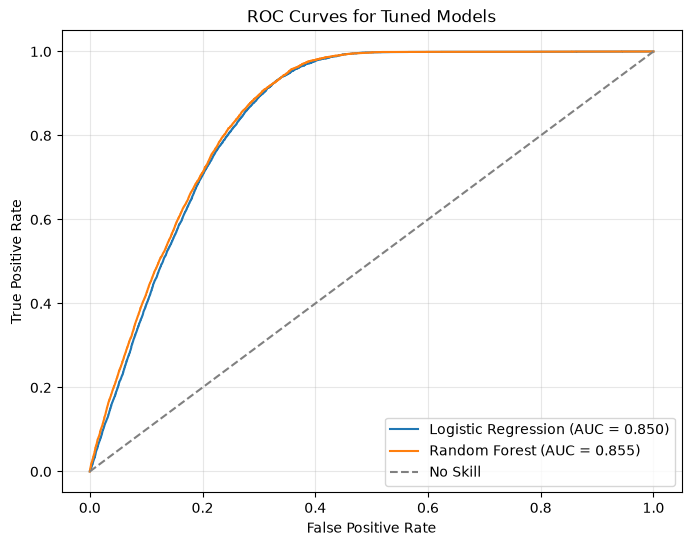

In [161]:
import matplotlib.pyplot as plt

logreg_fpr, logreg_tpr, _ = roc_curve(y_test, logreg_y_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_y_prob)

plt.figure(figsize=(8, 6))

plt.plot(
    logreg_fpr,
    logreg_tpr,
    label=f"Logistic Regression (AUC = {logreg_results['ROC-AUC'].iloc[0]:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_results['ROC-AUC'].iloc[0]:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    color="gray",
    label="No Skill"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Tuned Models")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.show()

# Additional Exploration — Association Analysis

In [169]:
from mlxtend.frequent_patterns import (
    apriori,
    association_rules
)

arm_data = X_train.copy()

arm_data["Response"] = y_train.values

arm_columns = [
    "Gender",
    "Previously_Insured",
    "Vehicle_Age",
    "Vehicle_Damage",
    "Age",
    "Annual_Premium",
    "Vintage",
    "Response"
]

arm_data = arm_data[arm_columns].copy()

In [171]:
arm_data["Age_Group"] = pd.qcut(
    arm_data["Age"],
    q=3,
    labels=["Younger", "Middle", "Older"],
    duplicates="drop"
)

arm_data["Premium_Group"] = pd.qcut(
    arm_data["Annual_Premium"],
    q=3,
    labels=["Low", "Medium", "High"],
    duplicates="drop"
)

arm_data["Vintage_Group"] = pd.qcut(
    arm_data["Vintage"],
    q=3,
    labels=["Short", "Medium", "Long"],
    duplicates="drop"
)

arm_data = arm_data.drop(
    columns=[
        "Age",
        "Annual_Premium",
        "Vintage"
    ]
)

arm_data.head()

,Gender,Previously_Insured,Vehicle_Age,Vehicle_Damage,Response,Age_Group,Premium_Group,Vintage_Group
274710,Male,0,< 1 Year,Yes,0,Younger,Low,Medium
216539,Female,1,< 1 Year,No,0,Younger,High,Short
78983,Female,0,< 1 Year,Yes,1,Middle,Medium,Short
218368,Male,0,< 1 Year,Yes,0,Middle,High,Long
307215,Female,0,< 1 Year,Yes,0,Younger,High,Long


In [143]:
arm_data = arm_data.astype(str)

arm_encoded = pd.get_dummies(
    arm_data,
    prefix_sep="="
).astype(bool)

arm_encoded.head()

,Gender=Female,Gender=Male,Previously_Insured=0,Previously_Insured=1,Vehicle_Age=1-2 Year,Vehicle_Age=< 1 Year,Vehicle_Age=> 2 Years,Vehicle_Damage=No,Vehicle_Damage=Yes,Response=0,Response=1,Age_Group=Middle,Age_Group=Older,Age_Group=Younger,Premium_Group=High,Premium_Group=Low,Premium_Group=Medium,Vintage_Group=Long,Vintage_Group=Medium,Vintage_Group=Short
274710,False,True,True,False,False,True,False,False,True,True,False,False,False,True,False,True,False,False,True,False
216539,True,False,False,True,False,True,False,True,False,True,False,False,False,True,True,False,False,False,False,True
78983,True,False,True,False,False,True,False,False,True,False,True,True,False,False,False,False,True,False,False,True
218368,False,True,True,False,False,True,False,False,True,True,False,True,False,False,True,False,False,True,False,False
307215,True,False,True,False,False,True,False,False,True,True,False,False,False,True,True,False,False,True,False,False


In [172]:
frequent_itemsets = apriori(
    arm_encoded,
    min_support=0.01,
    use_colnames=True,
    max_len=4,
    low_memory=True
)

frequent_itemsets = frequent_itemsets.sort_values(by="support", ascending=False)

print(frequent_itemsets.head(10))

print(
    f"Frequent itemsets found: {len(frequent_itemsets):,}"
)

      support                                               itemsets
9    0.877437                                frozenset({Response=0})
2    0.541873                      frozenset({Previously_Insured=0})
1    0.540463                               frozenset({Gender=Male})
4    0.525424                      frozenset({Vehicle_Age=1-2 Year})
8    0.504971                        frozenset({Vehicle_Damage=Yes})
7    0.495029                         frozenset({Vehicle_Damage=No})
118  0.492425             frozenset({Vehicle_Damage=No, Response=0})
60   0.479076  frozenset({Previously_Insured=0, Vehicle_Damage=Yes})
45   0.465841                   frozenset({Response=0, Gender=Male})
0    0.459537                             frozenset({Gender=Female})
Frequent itemsets found: 2,452


In [173]:
rules = association_rules(
    frequent_itemsets,
    metric="confidence",
    min_threshold=0.15
)

response_rules = rules[
    rules["consequents"] == frozenset({"Response=1"})
].copy()

response_rules = response_rules[
    ~response_rules["antecedents"].apply(
        lambda items:
        "Response=0" in items or
        "Response=1" in items
    )
]

response_rules = response_rules[
    [
        "antecedents",
        "consequents",
        "support",
        "confidence",
        "lift",
        "leverage",
        "conviction"
    ]
]

response_rules = response_rules[
    response_rules["lift"] > 1
]

response_rules = response_rules.sort_values(
    by=[
        "lift",
        "confidence",
        "support"
    ],
    ascending=False
)

print(
    f"Response Rules Found: {len(response_rules):,}"
)

Response Rules Found: 195


In [174]:
def format_itemset(itemset):
    return ", ".join(
        sorted(itemset)
    )

response_rules_display = response_rules.copy()

response_rules_display["antecedents"] = (
    response_rules_display["antecedents"]
    .apply(format_itemset)
)

response_rules_display["consequents"] = (
    response_rules_display["consequents"]
    .apply(format_itemset)
)

display(
    response_rules_display.head(10)
)

,antecedents,consequents,support,confidence,lift,leverage,conviction
14889,"Age_Group=Middle, Premium_Group=High, Vehicle_Damage=Yes",Response=1,0.020178,0.330575,2.697174,0.012697,1.310732
6703,"Age_Group=Middle, Previously_Insured=0, Vehicle_Damage=Yes",Response=1,0.058677,0.324665,2.648952,0.036526,1.299261
8725,"Age_Group=Middle, Vehicle_Age=1-2 Year, Vehicle_Damage=Yes",Response=1,0.047706,0.320142,2.612049,0.029442,1.290617
15256,"Age_Group=Middle, Premium_Group=Medium, Vehicle_Damage=Yes",Response=1,0.018859,0.320085,2.611583,0.011638,1.290508
15111,"Age_Group=Middle, Vehicle_Damage=Yes, Vintage_Group=Long",Response=1,0.019568,0.316902,2.585617,0.012000,1.284496
13738,"Age_Group=Middle, Gender=Female, Vehicle_Damage=Yes",Response=1,0.024776,0.316292,2.580638,0.015176,1.283350
14813,"Age_Group=Middle, Premium_Group=High, Previously_Insured=0",Response=1,0.020355,0.313577,2.558486,0.012399,1.278274
6661,"Age_Group=Middle, Vehicle_Damage=Yes",Response=1,0.058769,0.313088,2.554494,0.035763,1.277363
15054,"Age_Group=Middle, Vehicle_Damage=Yes, Vintage_Group=Short",Response=1,0.019788,0.312413,2.548987,0.012025,1.276109
11471,"Age_Group=Middle, Gender=Male, Vehicle_Damage=Yes",Response=1,0.033993,0.310793,2.535769,0.020588,1.273110


In [175]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)

response_rules_display["Rule"] = (
    response_rules_display["antecedents"]
    + " → "
    + response_rules_display["consequents"]
)

display(
    response_rules_display[
        [
            "Rule",
            "support",
            "confidence",
            "lift",
            "leverage",
            "conviction"
        ]
    ].head(10)
)

response_rules_display.sort_values(
    by="lift",
    ascending=False
).head(10)

,Rule,support,confidence,lift,leverage,conviction
14889,"Age_Group=Middle, Premium_Group=High, Vehicle_Damage=Yes → Response=1",0.020178,0.330575,2.697174,0.012697,1.310732
6703,"Age_Group=Middle, Previously_Insured=0, Vehicle_Damage=Yes → Response=1",0.058677,0.324665,2.648952,0.036526,1.299261
8725,"Age_Group=Middle, Vehicle_Age=1-2 Year, Vehicle_Damage=Yes → Response=1",0.047706,0.320142,2.612049,0.029442,1.290617
15256,"Age_Group=Middle, Premium_Group=Medium, Vehicle_Damage=Yes → Response=1",0.018859,0.320085,2.611583,0.011638,1.290508
15111,"Age_Group=Middle, Vehicle_Damage=Yes, Vintage_Group=Long → Response=1",0.019568,0.316902,2.585617,0.012000,1.284496
13738,"Age_Group=Middle, Gender=Female, Vehicle_Damage=Yes → Response=1",0.024776,0.316292,2.580638,0.015176,1.283350
14813,"Age_Group=Middle, Premium_Group=High, Previously_Insured=0 → Response=1",0.020355,0.313577,2.558486,0.012399,1.278274
6661,"Age_Group=Middle, Vehicle_Damage=Yes → Response=1",0.058769,0.313088,2.554494,0.035763,1.277363
15054,"Age_Group=Middle, Vehicle_Damage=Yes, Vintage_Group=Short → Response=1",0.019788,0.312413,2.548987,0.012025,1.276109
11471,"Age_Group=Middle, Gender=Male, Vehicle_Damage=Yes → Response=1",0.033993,0.310793,2.535769,0.020588,1.273110


,antecedents,consequents,support,confidence,lift,leverage,conviction,Rule
14889,"Age_Group=Middle, Premium_Group=High, Vehicle_Damage=Yes",Response=1,0.020178,0.330575,2.697174,0.012697,1.310732,"Age_Group=Middle, Premium_Group=High, Vehicle_Damage=Yes → Response=1"
6703,"Age_Group=Middle, Previously_Insured=0, Vehicle_Damage=Yes",Response=1,0.058677,0.324665,2.648952,0.036526,1.299261,"Age_Group=Middle, Previously_Insured=0, Vehicle_Damage=Yes → Response=1"
8725,"Age_Group=Middle, Vehicle_Age=1-2 Year, Vehicle_Damage=Yes",Response=1,0.047706,0.320142,2.612049,0.029442,1.290617,"Age_Group=Middle, Vehicle_Age=1-2 Year, Vehicle_Damage=Yes → Response=1"
15256,"Age_Group=Middle, Premium_Group=Medium, Vehicle_Damage=Yes",Response=1,0.018859,0.320085,2.611583,0.011638,1.290508,"Age_Group=Middle, Premium_Group=Medium, Vehicle_Damage=Yes → Response=1"
15111,"Age_Group=Middle, Vehicle_Damage=Yes, Vintage_Group=Long",Response=1,0.019568,0.316902,2.585617,0.012000,1.284496,"Age_Group=Middle, Vehicle_Damage=Yes, Vintage_Group=Long → Response=1"
13738,"Age_Group=Middle, Gender=Female, Vehicle_Damage=Yes",Response=1,0.024776,0.316292,2.580638,0.015176,1.283350,"Age_Group=Middle, Gender=Female, Vehicle_Damage=Yes → Response=1"
14813,"Age_Group=Middle, Premium_Group=High, Previously_Insured=0",Response=1,0.020355,0.313577,2.558486,0.012399,1.278274,"Age_Group=Middle, Premium_Group=High, Previously_Insured=0 → Response=1"
6661,"Age_Group=Middle, Vehicle_Damage=Yes",Response=1,0.058769,0.313088,2.554494,0.035763,1.277363,"Age_Group=Middle, Vehicle_Damage=Yes → Response=1"
15054,"Age_Group=Middle, Vehicle_Damage=Yes, Vintage_Group=Short",Response=1,0.019788,0.312413,2.548987,0.012025,1.276109,"Age_Group=Middle, Vehicle_Damage=Yes, Vintage_Group=Short → Response=1"
11471,"Age_Group=Middle, Gender=Male, Vehicle_Damage=Yes",Response=1,0.033993,0.310793,2.535769,0.020588,1.273110,"Age_Group=Middle, Gender=Male, Vehicle_Damage=Yes → Response=1"
